# Notebook 2 - Integracion de fuentes complementarias

**TFG - Comunidad Valenciana | Continuidad de la ingenieria del dato**

Este cuaderno continua la fase de ingenieria del dato iniciada en el Notebook 1. Su objetivo es enriquecer la base municipal climatica-geoespacial ya consolidada mediante la incorporacion de fuentes externas complementarias, priorizando en esta fase las variables municipales del `INE`.

En particular, este notebook se orienta a:
- cargar el dataset municipal base generado en el Notebook 1,
- integrar variables municipales de `poblacion`, `edad` y `renta` procedentes del `INE`,
- armonizar claves y estructuras territoriales,
- validar la consistencia del dataset enriquecido,
- y exportar una salida reutilizable para fases posteriores del TFG.

La integracion prioritaria con `INE` constituye el desarrollo principal de este notebook, mientras que `AEMET` se incorpora ya como bloque de validacion externa exploratoria del componente climatico. La posible incorporacion de informacion de exposicion territorial procedente de `Catastro` se mantiene como linea futura sobre esta misma base.


## 0) Configuracion inicial, rutas y alcance

Este notebook no sustituye al Notebook 1, sino que se apoya sobre su salida principal (`dataset_cv_municipios.csv`) para enriquecer la base municipal del TFG con nuevas variables territoriales y socioeconómicas.

En esta fase, la ampliacion del dataset se centra prioritariamente en la integracion de fuentes del `INE`, incorporando informacion municipal de `poblacion`, `edad` y `renta`. El procesamiento se plantea de forma modular para mantener la trazabilidad del pipeline, facilitar ejecuciones parciales y permitir la incorporacion posterior de otras fuentes complementarias si resultan pertinentes.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "DATA"
EXT = DATA / "EXTERNAL"
PROC = DATA / "PROCESSED"

BASE_FILE = PROC / "dataset_cv_municipios.csv"
MUN_FILE = EXT / "municipios_cv.geojson"
INE_DIR = EXT / "ine"
INE_CONTEXT_FILE = PROC / "ine_contexto_municipal.csv"
ENRICHED_FILE = PROC / "dataset_cv_municipios_enriched.csv"

print("ROOT:", ROOT)
print("BASE_FILE:", BASE_FILE, "| existe:", BASE_FILE.exists())
print("MUN_FILE:", MUN_FILE, "| existe:", MUN_FILE.exists())
print("INE_DIR:", INE_DIR, "| existe:", INE_DIR.exists())


ROOT: c:\Users\gonza\OneDrive\tfg
BASE_FILE: c:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios.csv | existe: True
MUN_FILE: c:\Users\gonza\OneDrive\tfg\DATA\EXTERNAL\municipios_cv.geojson | existe: True
INE_DIR: c:\Users\gonza\OneDrive\tfg\DATA\EXTERNAL\ine | existe: True


## 1) Carga de la base municipal generada en el Notebook 1

Como punto de partida se recupera el dataset municipal diario consolidado en el Notebook 1. Este fichero constituye la base operativa sobre la que se integraran las variables territoriales y socioeconomicas complementarias incorporadas en esta fase de la ingenieria del dato.


In [2]:
assert BASE_FILE.exists(), f"No se encontro {BASE_FILE}"

df_base = pd.read_csv(BASE_FILE, parse_dates=["fecha"])

print("Shape:", df_base.shape)
print("Municipios:", df_base["municipio"].nunique())
print("Rango temporal:", df_base["fecha"].min(), "->", df_base["fecha"].max())
display(df_base.head(3))

print("Duplicados municipio-fecha:", df_base.duplicated(subset=["municipio", "fecha"]).sum())


Shape: (1188064, 14)
Municipios: 542
Rango temporal: 2019-01-01 00:00:00 -> 2024-12-31 00:00:00


,municipio,CODNUT2,CODNUT3,fecha,temp_media_dia,temp_max_dia,temp_min_dia,viento_medio_dia,viento_max_dia,lon,lat,dist_metros,precip_total_dia,amplitud_termica_dia
0,Ademuz,ES52,ES523,2019-01-01,2.735280,12.305084,-2.840179,1.430405,1.927332,-1.2,40.1,5806.682345,0.00000,15.145263
1,Ademuz,ES52,ES523,2019-01-02,1.408661,8.768463,-2.744965,2.487614,3.134458,-1.2,40.1,5806.682345,0.00086,11.513428
2,Ademuz,ES52,ES523,2019-01-03,1.463847,7.518707,-3.328705,1.271294,1.983465,-1.2,40.1,5806.682345,0.00000,10.847412


Duplicados municipio-fecha: 0


La carga de la base municipal confirma la disponibilidad del dataset diario consolidado generado en el Notebook 1, que mantiene cobertura completa para los municipios de la Comunidad Valenciana y una granularidad temporal diaria. Esta estructura servira como soporte comun para integrar el contexto territorial adicional sin modificar la unidad analitica principal del proyecto.


## 2) Trazabilidad y priorizacion de las fuentes complementarias

Una vez construida en el Notebook 1 la base climatica-geoespacial municipal a partir de `ERA5-Land` e `IGN`, esta segunda fase de la ingenieria del dato incorpora fuentes complementarias orientadas a enriquecer la caracterizacion territorial del riesgo climatico.

En esta etapa se priorizan tres bloques de informacion del `Instituto Nacional de Estadistica (INE)`:

- **Poblacion municipal total**, obtenida a partir del `Padron` y de las cifras oficiales de poblacion municipal.
- **Estructura demografica por edad**, obtenida del `Censo anual de poblacion`.
- **Renta municipal**, obtenida del `Atlas de distribucion de renta de los hogares`.

Los ficheros originales se descargan en formato `XLSX` desde las operaciones oficiales del INE y se almacenan en `DATA/EXTERNAL/ine`, manteniendo su caracter de fuente externa bruta. En concreto, se utilizan los siguientes archivos:

- `alicante poblacion.xlsx`, `castellon poblacion.xlsx`, `valencia poblacion.xlsx`
- `ine_edad_municipal.xlsx`
- `alicante_renta.xlsx`, `castellon_renta.xlsx`, `valencia_renta.xlsx`

Estas fuentes se integran mediante un procesamiento reproducible apoyado en el script `prepare_ine_municipal.py`, que extrae las variables de interes desde los ficheros originales, armoniza la identificacion municipal y genera una tabla municipal consolidada lista para su union con la base diaria construida en el Notebook 1.

**Referencias oficiales del INE**
- Padron y cifras oficiales de poblacion municipal: https://www.ine.es/dynt3/inebase/es/index.htm?capsel=525&padre=9041
- Censo anual de poblacion: https://www.ine.es/dyngs/INEbase/operacion.htm?c=Estadistica_C&cid=1254736176992&idp=1254735576757&menu=resultados
- Atlas de distribucion de renta de los hogares: https://www.ine.es/dynt3/inebase/es/index.htm?capsel=12384&padre=12385


### 2.1) Priorizacion de fuentes complementarias

Con el fin de orientar la continuidad de la ingenieria del dato hacia variables realmente utiles para el TFG, se establece una priorizacion inicial de fuentes complementarias en funcion de su capacidad para aportar informacion sobre exposicion, vulnerabilidad y validacion externa del bloque climatico.

| Fuente / dataset | Variables objetivo | Utilidad en el TFG | Prioridad |
|---|---|---|---|
| `INE - Poblacion municipal` | `poblacion_total` | Mide la exposicion humana basica a escala municipal | Alta |
| `INE - Poblacion por edad` | `% mayores_65`, `% menores_16`, `indice_envejecimiento` | Introduce vulnerabilidad demografica frente a fenomenos climaticos | Alta |
| `INE - Atlas de renta municipal` | `renta_media_hogar` o equivalente | Introduce vulnerabilidad socioeconomica y capacidad de adaptacion | Alta |
| `INE / Censo 2021 - Viviendas` | `num_viviendas`, hogares o parque residencial | Aproxima exposicion territorial o residencial | Media-Alta |
| `AEMET OpenData` | temperatura y precipitacion observada | Permite validar externamente la coherencia del bloque climatico ERA5 | Media-Alta |
| `Catastro` | parque edificado, tipologia, antiguedad o intensidad edificatoria | Refuerza la medicion de exposicion fisica y valor territorial | Media |
| `Indicadores Urbanos` | indicadores socioeconomicos o urbanos | Utiles para subanalisis de ciudades o municipios grandes | Media-Baja |
| `Indicadores Demograficos Basicos` | variables demograficas agregadas | Utiles si se plantea un analisis especifico sobre municipios grandes | Media-Baja |

A partir de esta priorizacion, la continuidad del notebook se centra inicialmente en las fuentes del `INE` con mayor cobertura municipal (`poblacion`, `edad` y `renta`), dejando para fases posteriores la incorporacion de fuentes mas especificas o complejas, como `Catastro` o determinadas validaciones externas con `AEMET`.


## 3) Integración prioritaria de variables municipales del INE

La primera ampliacion operativa del dataset base se centra en tres bloques del `INE` con alta utilidad para el TFG: `poblacion`, `edad` y `renta`. Estas variables permiten incorporar dimensiones de exposicion y vulnerabilidad territorial a la base climatica-geoespacial construida previamente en el Notebook 1.

La integracion se apoya en los siguientes conjuntos de datos:

- Los ficheros `alicante poblacion.xlsx`, `castellon poblacion.xlsx` y `valencia poblacion.xlsx`, descargados del `Padron`, permiten extraer la `poblacion_total` municipal.
- El fichero `ine_edad_municipal.xlsx`, descargado del `Censo anual de poblacion`, permite construir indicadores demograficos como `mayores_65_pct`, `menores_16_pct` e `indice_envejecimiento`.
- Los ficheros `alicante_renta.xlsx`, `castellon_renta.xlsx` y `valencia_renta.xlsx`, descargados del `Atlas de distribucion de renta de los hogares`, permiten extraer la variable `renta_media_hogar`.

A partir de estos archivos, el script `prepare_ine_municipal.py` realiza la extraccion de las variables de interes, armoniza la identificacion municipal, integra los distintos bloques a traves del `cod_ine` y genera una tabla municipal consolidada. Sobre esta salida se calcula ademas la `densidad_poblacion` utilizando la superficie municipal derivada de la capa geoespacial del `IGN`.


### 3.1) Trazabilidad de los ficheros descargados del INE

Antes de construir la tabla municipal de contexto, se comprueba la disponibilidad de los ficheros descargados del `INE` y su correspondencia con los bloques de informacion priorizados (`poblacion`, `edad` y `renta`). Esta verificacion permite asegurar que la integracion parte de fuentes externas correctamente depositadas en `DATA/EXTERNAL/ine` y que el pipeline cuenta con los insumos necesarios para su ejecucion.


In [3]:
import sys

if str(ROOT / "scripts") not in sys.path:
    sys.path.append(str(ROOT / "scripts"))

from prepare_ine_municipal import EXPECTED_FILES, build_ine_context

print("Directorio INE:", INE_DIR)
print("Existe:", INE_DIR.exists())

print("\nFicheros esperados por bloque:")
for stem, spec in EXPECTED_FILES.items():
    print(f"- {stem}: {spec['description']}")
    print(f"  ficheros: {spec['files']}")
    print(f"  variables extraidas: {spec['required']}")

if INE_DIR.exists():
    files = sorted(INE_DIR.glob("*"))
    print("\nFicheros disponibles en INE:")
    display(pd.DataFrame({"file": [p.name for p in files]}))
else:
    print("No hay ficheros INE preparados todavia.")


Directorio INE: c:\Users\gonza\OneDrive\tfg\DATA\EXTERNAL\ine
Existe: True

Ficheros esperados por bloque:
- poblacion: Padron municipal por provincias para Alicante, Castellon y Valencia
  ficheros: ['alicante poblacion.xlsx', 'castellon poblacion.xlsx', 'valencia poblacion.xlsx']
  variables extraidas: ['cod_ine', 'municipio', 'poblacion_total']
- edad: Censo anual de poblacion por sexo y edad (archivo nacional completo)
  ficheros: ['ine_edad_municipal.xlsx']
  variables extraidas: ['cod_ine', 'municipio', 'mayores_65_pct', 'menores_16_pct', 'indice_envejecimiento']
- renta: Atlas de renta por provincias con el indicador de renta neta media por hogar
  ficheros: ['alicante_renta.xlsx', 'castellon_renta.xlsx', 'valencia_renta.xlsx']
  variables extraidas: ['cod_ine', 'municipio', 'renta_media_hogar']

Ficheros disponibles en INE:


,file
0,alicante poblacion.xlsx
1,alicante_renta.xlsx
2,castellon poblacion.xlsx
3,castellon_renta.xlsx
4,ine_edad_municipal.xlsx
5,valencia poblacion.xlsx
6,valencia_renta.xlsx


La comprobacion de trazabilidad confirma la disponibilidad de los ficheros necesarios para abordar la integracion prioritaria del `INE`. Esta verificacion refuerza la reproducibilidad del proceso, ya que deja identificado de forma explicita que variables aporta cada bloque tematico y que archivos concretos alimentan la construccion posterior de la tabla municipal de contexto.


### 3.2) Construccion de la tabla municipal de contexto

Una vez verificada la disponibilidad de los ficheros descargados, se construye una tabla municipal de contexto con una sola fila por municipio. Esta tabla integra las variables priorizadas del `INE` y queda preparada para su posterior union con la base diaria generada en el Notebook 1.

El proceso se apoya en el script `prepare_ine_municipal.py`, que extrae las variables de interes desde los archivos originales, armoniza la identificacion municipal, integra los distintos bloques mediante `cod_ine` y calcula la `densidad_poblacion` a partir de la superficie municipal.


In [4]:
try:
    df_ine = build_ine_context(INE_DIR, MUN_FILE)
    df_ine.to_csv(INE_CONTEXT_FILE, index=False)

    print("Tabla INE generada en:", INE_CONTEXT_FILE)
    print("Shape:", df_ine.shape)
    print("Municipios:", df_ine["municipio"].nunique())
    print("Nulos por columna:")
    print(df_ine.isna().sum())

    display(df_ine.head(5))
except FileNotFoundError as exc:
    print(exc)
    df_ine = None
except Exception as exc:
    print("Error durante la construccion de la tabla INE:", exc)
    df_ine = None


Tabla INE generada en: c:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\ine_contexto_municipal.csv
Shape: (542, 11)
Municipios: 542
Nulos por columna:
municipio                0
CODNUT2                  0
CODNUT3                  0
area_km2                 0
cod_ine                  0
poblacion_total          0
densidad_poblacion       0
mayores_65_pct           0
menores_16_pct           0
indice_envejecimiento    5
renta_media_hogar        8
dtype: int64


,municipio,CODNUT2,CODNUT3,area_km2,cod_ine,poblacion_total,densidad_poblacion,mayores_65_pct,menores_16_pct,indice_envejecimiento,renta_media_hogar
0,Agost,ES52,ES521,66.6538,03002,5225.0,78.39,20.27,13.84,146.47,30407.0
1,Agres,ES52,ES521,25.8457,03003,623.0,24.10,24.80,11.36,218.31,31440.0
2,Aigües,ES52,ES521,18.4797,03004,1199.0,64.88,20.22,15.33,131.87,32937.0
3,Alacant/Alicante,ES52,ES521,202.6445,03014,366221.0,1807.21,19.87,14.36,138.39,34936.0
4,Albatera,ES52,ES521,61.8796,03005,13566.0,219.23,15.97,18.25,87.48,29376.0


La construccion de `df_ine` permite consolidar en una unica tabla municipal las variables priorizadas del `INE`, manteniendo una fila por municipio y cobertura territorial completa para la Comunidad Valenciana. Esta salida resume en una misma estructura dimensiones de `exposicion` (`poblacion_total`, `densidad_poblacion`) y `vulnerabilidad` (`mayores_65_pct`, `menores_16_pct`, `indice_envejecimiento`, `renta_media_hogar`), reforzando el valor analitico del dataset base.

Los valores ausentes residuales responden a limitaciones puntuales de disponibilidad en algunas tablas del `INE`, no a errores del proceso de integracion. En particular, los nulos del `indice_envejecimiento` aparecen en municipios donde el denominador asociado a la poblacion menor de 16 anos hace que el indicador no resulte interpretable, mientras que los pocos nulos de `renta_media_hogar` reflejan ausencia de dato en la fuente original.


Como comprobacion visual complementaria, se representa la `densidad_poblacion` municipal derivada del cruce entre poblacion del `INE` y superficie municipal del `IGN`. Este mapa no pretende realizar todavia un analisis territorial exhaustivo, sino verificar que la nueva capa de contexto presenta una distribucion espacial coherente a escala municipal.


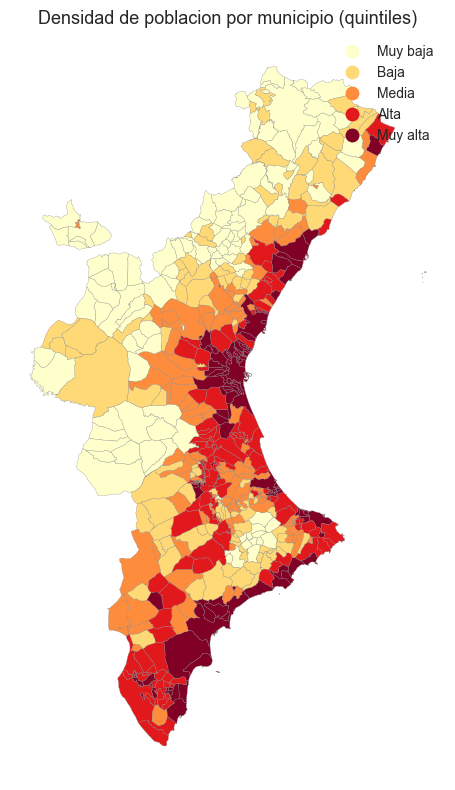

In [7]:
if df_ine is not None:
    gdf_ine_map = gpd.read_file(MUN_FILE).merge(
        df_ine[["municipio", "densidad_poblacion"]],
        on="municipio",
        how="left",
        validate="one_to_one",
    )

    gdf_ine_map["densidad_quintil"] = pd.qcut(
        gdf_ine_map["densidad_poblacion"],
        q=5,
        labels=[
            "Muy baja",
            "Baja",
            "Media",
            "Alta",
            "Muy alta",
        ],
        duplicates="drop",
    )

    ax = gdf_ine_map.plot(
        column="densidad_quintil",
        cmap="YlOrRd",
        legend=True,
        figsize=(8, 8),
        edgecolor="grey",
        linewidth=0.2,
        missing_kwds={
            "color": "lightgrey",
            "label": "Sin datos",
        },
    )

    ax.set_title("Densidad de poblacion por municipio (quintiles)", fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print("No se puede representar el mapa porque df_ine no esta disponible.")


La densidad de población presenta una distribución muy asimétrica, con pocos municipios de densidad muy elevada frente a una mayoría de municipios con valores bajos o medios. Por este motivo, el mapa se representa mediante quintiles, facilitando la comparación relativa entre municipios y evitando que los valores extremos oculten la variabilidad territorial intermedia.


### 3.3) Integracion del contexto INE en la base diaria

Una vez construida la tabla municipal del `INE`, se procede a su integracion sobre la base diaria generada en el Notebook 1. Dado que la informacion del `INE` tiene caracter estatico a escala municipal, la union se realiza mediante una relacion `many_to_one`: muchas observaciones diarias por municipio frente a una unica fila de contexto por municipio.

Este paso permite enriquecer el dataset climatico diario con variables demograficas, socioeconomicas y territoriales sin alterar su granularidad temporal original.


In [8]:
if df_ine is not None:
    df_enriched = df_base.merge(
        df_ine,
        on=["municipio", "CODNUT2", "CODNUT3"],
        how="left",
        validate="many_to_one",
    )
else:
    df_enriched = df_base.copy()

print("Shape dataset enriquecido:", df_enriched.shape)

display(df_enriched.head(3))


Shape dataset enriquecido: (1188064, 22)


,municipio,CODNUT2,CODNUT3,fecha,temp_media_dia,temp_max_dia,temp_min_dia,viento_medio_dia,viento_max_dia,lon,lat,dist_metros,precip_total_dia,amplitud_termica_dia,area_km2,cod_ine,poblacion_total,densidad_poblacion,mayores_65_pct,menores_16_pct,indice_envejecimiento,renta_media_hogar
0,Ademuz,ES52,ES523,2019-01-01,2.735280,12.305084,-2.840179,1.430405,1.927332,-1.2,40.1,5806.682345,0.00000,15.145263,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0
1,Ademuz,ES52,ES523,2019-01-02,1.408661,8.768463,-2.744965,2.487614,3.134458,-1.2,40.1,5806.682345,0.00086,11.513428,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0
2,Ademuz,ES52,ES523,2019-01-03,1.463847,7.518707,-3.328705,1.271294,1.983465,-1.2,40.1,5806.682345,0.00000,10.847412,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0


La integracion del contexto municipal del `INE` sobre la base diaria se completa sin modificar la estructura temporal del dataset, manteniendo una observacion por municipio y fecha. Como resultado, cada registro diario incorpora una capa adicional de contexto territorial que amplia la capacidad analitica del dataset mas alla de la dimension estrictamente climatica.

Este enriquecimiento permite abordar fases posteriores del TFG con una base mas completa, en la que los patrones meteorologicos pueden relacionarse con factores de exposicion y vulnerabilidad municipal.


### 3.4) Validacion del dataset enriquecido

Tras la integracion del contexto municipal del `INE`, se realizan comprobaciones basicas para verificar que el dataset enriquecido mantiene la estructura esperada del Notebook 1 y que las nuevas variables se incorporan sin introducir inconsistencias en la granularidad diaria.

En particular, se revisan la cobertura municipal, la ausencia de duplicados en la combinacion `municipio-fecha`, y la presencia de valores nulos en las variables incorporadas desde el `INE`.


In [9]:
print("Shape dataset enriquecido:", df_enriched.shape)
print("Municipios:", df_enriched["municipio"].nunique())
print("Duplicados municipio-fecha:", df_enriched.duplicated(subset=["municipio", "fecha"]).sum())

print("\nNulos en variables INE:")
cols_ine = [
    "area_km2",
    "cod_ine",
    "poblacion_total",
    "densidad_poblacion",
    "mayores_65_pct",
    "menores_16_pct",
    "indice_envejecimiento",
    "renta_media_hogar",
]
cols_ine = [c for c in cols_ine if c in df_enriched.columns]
print(df_enriched[cols_ine].isna().sum())

print("\nResumen descriptivo de variables INE:")
display(df_enriched[cols_ine].describe().T)

print("\nMunicipios con algun nulo en variables INE:")
display(
    df_enriched.loc[df_enriched[cols_ine].isna().any(axis=1), ["municipio"] + cols_ine]
    .drop_duplicates()
    .sort_values("municipio")
)



Shape dataset enriquecido: (1188064, 22)
Municipios: 542
Duplicados municipio-fecha: 0

Nulos en variables INE:
area_km2                     0
cod_ine                      0
poblacion_total              0
densidad_poblacion           0
mayores_65_pct               0
menores_16_pct               0
indice_envejecimiento    10960
renta_media_hogar        17536
dtype: int64

Resumen descriptivo de variables INE:


,count,mean,std,min,25%,50%,75%,max
area_km2,1188064.0,42.939165,62.611683,0.0126,9.111,21.97355,55.5983,814.269
poblacion_total,1188064.0,9992.330258,43029.790996,21.0000,503.000,1561.00000,7717.0000,840792.000
densidad_poblacion,1188064.0,580.056642,2053.352498,0.6800,15.980,87.81000,399.0400,24305.560
mayores_65_pct,1188064.0,24.904244,6.994269,9.5200,19.810,23.20000,29.4700,49.030
menores_16_pct,1188064.0,11.921716,3.801276,0.0000,9.650,12.88500,14.4900,22.430



Municipios con algun nulo en variables INE:


,municipio,area_km2,cod_ine,poblacion_total,densidad_poblacion,mayores_65_pct,menores_16_pct,indice_envejecimiento,renta_media_hogar
258656,Benimassot,9.5184,03039,85.0,8.93,36.47,2.35,1550.0,<NA>
344144,Carrícola,4.6011,46086,97.0,21.08,29.17,3.12,933.33,<NA>
477856,Espadilla,11.9686,12058,101.0,8.44,24.51,7.84,312.5,<NA>
486624,Famorca,9.7301,03068,44.0,4.52,47.73,0.00,<NA>,<NA>
510736,Fuente la Reina,7.4194,12063,55.0,7.41,22.22,0.00,<NA>,29636.0
771584,Puebla de San Miguel,63.6002,46201,53.0,0.83,35.85,3.77,950.0,<NA>
883376,Sempere,3.8095,46226,33.0,8.66,42.42,0.00,<NA>,<NA>
942560,Tollos,15.9839,03130,32.0,2.00,47.06,0.00,<NA>,<NA>
990784,Vallat,5.0075,12123,66.0,13.18,14.71,2.94,500.0,<NA>
1030240,Villores,5.3082,12137,51.0,9.61,25.49,0.00,<NA>,26601.0


La validacion confirma que el dataset enriquecido mantiene la estructura diaria original del Notebook 1, sin introducir duplicados en la clave `municipio-fecha` y conservando cobertura completa para los municipios de la Comunidad Valenciana. Las nuevas variables territoriales del `INE` se incorporan de forma consistente, reforzando la capacidad analitica del dataset sin alterar su unidad de observacion.

Los pocos valores ausentes observados en algunas variables responden a limitaciones puntuales de disponibilidad en la fuente original, especialmente en `renta_media_hogar` y en ciertos casos del `indice_envejecimiento`, y no a errores de integracion del pipeline.


### 3.5) Exportacion del dataset enriquecido

Una vez validada la consistencia estructural del dataset enriquecido, se procede a su exportacion en formato tabular para su reutilizacion en las fases posteriores del TFG.

Este fichero constituye la salida principal del Notebook 2 y recoge la integracion entre la base climatica-geoespacial construida en el Notebook 1 y las variables territoriales y socioeconomicas municipales incorporadas desde el `INE`.


In [10]:
ENRICHED_FILE = PROC / "dataset_cv_municipios_enriched.csv"

df_enriched.to_csv(ENRICHED_FILE, index=False)

print("Dataset enriquecido guardado en:", ENRICHED_FILE)
print("Shape:", df_enriched.shape)


Dataset enriquecido guardado en: c:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_enriched.csv
Shape: (1188064, 22)


El fichero exportado `dataset_cv_municipios_enriched.csv` constituye la salida principal de esta segunda fase de la ingenieria del dato. En el se conserva la estructura diaria municipal del bloque climatico original, enriquecida ahora con variables de contexto territorial y socioeconomico procedentes del `INE`, quedando preparado para las fases posteriores de analisis del dato.


### 3.6) Diccionario de datos de las nuevas variables

A continuacion se documentan las variables incorporadas al dataset enriquecido en esta fase del pipeline, indicando su significado, unidad, origen y granularidad. Este bloque facilita la interpretacion de la salida final y refuerza la trazabilidad de las nuevas dimensiones territoriales integradas desde el `INE`.


| Columna | Significado | Unidad | Origen | Granularidad |
|---|---|---|---|---|
| `cod_ine` | Codigo INE del municipio | - | INE | Municipio-día |
| `area_km2` | Superficie municipal derivada de la geometria oficial | km² | IGN | Municipio-día |
| `poblacion_total` | Poblacion total del municipio | personas | INE - Padron | Municipio-día |
| `densidad_poblacion` | Cociente entre poblacion total y superficie municipal | hab/km² | INE + IGN | Municipio-día |
| `mayores_65_pct` | Porcentaje de poblacion de 65 o mas años | % | INE - Censo anual de poblacion | Municipio-día |
| `menores_16_pct` | Porcentaje de poblacion menor de 16 años | % | INE - Censo anual de poblacion | Municipio-día |
| `indice_envejecimiento` | Relacion entre poblacion mayor de 64 años y poblacion menor de 16 años | indice | INE - Censo anual de poblacion | Municipio-día |
| `renta_media_hogar` | Renta neta media por hogar en el municipio | euros | INE - Atlas de renta | Municipio-día |


Estas variables amplian la base climatica-geoespacial del Notebook 1 con informacion demografica, socioeconomica y territorial relevante para fases posteriores del TFG, permitiendo relacionar la dimension meteorologica con factores de exposicion y vulnerabilidad municipal.


## 4) Validacion externa exploratoria con AEMET

Con el fin de contrastar de forma preliminar la coherencia del bloque climatico generado a partir de `ERA5-Land`, se incorpora una validacion externa basada en observaciones oficiales de `AEMET OpenData`.

Esta validacion no persigue todavia una calibracion exhaustiva del dataset, sino una comprobacion exploratoria de su comportamiento frente a datos observados en estaciones meteorologicas de la Comunidad Valenciana. Para ello se emplean los artefactos generados por el script `validate_aemet_vs_era5.py`, que descarga estaciones, recupera observaciones diarias y construye tablas comparativas con el dataset municipal del Notebook 1.


### 4.1) Disponibilidad de artefactos de validacion


In [22]:
AEMET_STATIONS_FILE = PROC / "aemet_selected_stations_cv.csv"
AEMET_RAW_FILE = PROC / "aemet_daily_raw_selected.csv"
AEMET_COMPARE_FILE = PROC / "aemet_vs_era5_daily_comparison.csv"
AEMET_METRICS_FILE = PROC / "aemet_vs_era5_metrics.csv"

print("Existe estaciones seleccionadas:", AEMET_STATIONS_FILE.exists())
print("Existe serie diaria AEMET:", AEMET_RAW_FILE.exists())
print("Existe tabla comparativa:", AEMET_COMPARE_FILE.exists())
print("Existe tabla de metricas:", AEMET_METRICS_FILE.exists())


Existe estaciones seleccionadas: True
Existe serie diaria AEMET: True
Existe tabla comparativa: True
Existe tabla de metricas: True


La validacion exploratoria con `AEMET` se apoya en un conjunto reducido de artefactos intermedios generados mediante script, lo que permite desacoplar la descarga de datos de la fase de analisis en notebook. Esta organizacion mantiene la trazabilidad del pipeline y facilita la reutilizacion posterior de los resultados de contraste sin depender de nuevas peticiones a la API en cada ejecucion.


### 4.2) Inspeccion de estaciones seleccionadas y cobertura temporal


In [23]:
if AEMET_STATIONS_FILE.exists():
    df_aemet_stations = pd.read_csv(AEMET_STATIONS_FILE)
    print("Shape estaciones:", df_aemet_stations.shape)
    print("Estaciones seleccionadas:", df_aemet_stations["indicativo"].astype(str).nunique())
    display(df_aemet_stations)
else:
    df_aemet_stations = None
    print("No existe el fichero de estaciones seleccionadas.")

if AEMET_RAW_FILE.exists():
    df_aemet_raw = pd.read_csv(AEMET_RAW_FILE, parse_dates=["fecha"])
    print("\nShape serie diaria AEMET:", df_aemet_raw.shape)
    print("Rango temporal:", df_aemet_raw["fecha"].min(), "->", df_aemet_raw["fecha"].max())
    print("Estaciones con datos:", df_aemet_raw["indicativo"].astype(str).nunique())
    print("Dias observados:", len(df_aemet_raw))
    print("Filas con tmed disponible:", df_aemet_raw["tmed"].notna().sum())

    if df_aemet_stations is not None:
        estaciones_seleccionadas = set(df_aemet_stations["indicativo"].astype(str))
        estaciones_con_datos = set(df_aemet_raw["indicativo"].astype(str))
        estaciones_sin_datos = sorted(estaciones_seleccionadas - estaciones_con_datos)
        print("Estaciones sin datos:", estaciones_sin_datos)

    display(df_aemet_raw.head(5))
else:
    df_aemet_raw = None
    print("No existe el fichero de serie diaria AEMET.")

Shape estaciones: (2, 8)
Estaciones seleccionadas: 2


,indicativo,nombre,provincia,altitud,municipio,CODNUT3,CODNUT3_prov,dist_ref_m
0,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,Onda,ES522,ES522,33368.421646
1,8058X,OLIVA,VALENCIA,1,Aielo de Malferit,ES523,ES523,51191.160277



Shape serie diaria AEMET: (123, 11)
Rango temporal: 2024-07-01 00:00:00 -> 2024-10-31 00:00:00
Estaciones con datos: 1
Dias observados: 123
Filas con tmed disponible: 0
Estaciones sin datos: ['8058X']


,fecha,indicativo,nombre,provincia,altitud,prec,tmed,municipio,CODNUT3,CODNUT3_prov,dist_ref_m
0,2024-07-01,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,4.5,NaN,Onda,ES522,ES522,33368.421646
1,2024-07-02,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,0.0,NaN,Onda,ES522,ES522,33368.421646
2,2024-07-03,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,0.0,NaN,Onda,ES522,ES522,33368.421646
3,2024-07-04,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,0.0,NaN,Onda,ES522,ES522,33368.421646
4,2024-07-05,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,0.0,NaN,Onda,ES522,ES522,33368.421646


La inspeccion de los artefactos generados permite identificar las estaciones seleccionadas para la validacion y comprobar la cobertura temporal realmente disponible en la descarga. En la ejecucion actual para el periodo comprendido entre el `1 de julio de 2024` y el `31 de octubre de 2024`, se seleccionan dos estaciones de referencia, pero solo una aporta observaciones diarias utilizables, lo que reduce el alcance efectivo del contraste frente a `ERA5-Land`.

Esta revision resulta especialmente importante porque la disponibilidad de datos observados en `AEMET` puede variar entre estaciones, periodos y variables. En este caso, la cobertura obtenida proporciona `123` observaciones diarias y es suficiente para una validacion preliminar de precipitacion, pero no para una evaluacion concluyente de temperatura.

### 4.3) Revision de la tabla comparativa y de las metricas de contraste


In [24]:
if AEMET_COMPARE_FILE.exists():
    df_aemet_compare = pd.read_csv(AEMET_COMPARE_FILE, parse_dates=["fecha"])
    print("Shape tabla comparativa:", df_aemet_compare.shape)
    print("Rango temporal:", df_aemet_compare["fecha"].min(), "->", df_aemet_compare["fecha"].max())
    print("Estaciones en comparacion:", df_aemet_compare["indicativo"].nunique())
    display(df_aemet_compare.head(5))
else:
    df_aemet_compare = None
    print("No existe la tabla comparativa AEMET vs ERA5.")

if AEMET_METRICS_FILE.exists():
    df_aemet_metrics = pd.read_csv(AEMET_METRICS_FILE)
    print("\nShape metricas:", df_aemet_metrics.shape)
    if "n_obs" in df_aemet_metrics.columns:
        print("Observaciones usadas en metricas:", df_aemet_metrics["n_obs"].sum())
    display(df_aemet_metrics)
else:
    df_aemet_metrics = None
    print("No existe la tabla de metricas.")


Shape tabla comparativa: (123, 13)
Rango temporal: 2024-07-01 00:00:00 -> 2024-10-31 00:00:00
Estaciones en comparacion: 1


,fecha,indicativo,nombre,provincia,altitud,prec,tmed,municipio,CODNUT3,CODNUT3_prov,dist_ref_m,precip_total_dia,temp_media_dia
0,2024-07-01,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,4.5,NaN,Onda,ES522,ES522,33368.421646,18.886675,21.996613
1,2024-07-02,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,0.0,NaN,Onda,ES522,ES522,33368.421646,0.000000,22.223348
2,2024-07-03,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,0.0,NaN,Onda,ES522,ES522,33368.421646,0.000000,23.370493
3,2024-07-04,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,0.0,NaN,Onda,ES522,ES522,33368.421646,0.001717,23.317200
4,2024-07-05,8501,CASTELLÓ DE LA PLANA,CASTELLON,23,0.0,NaN,Onda,ES522,ES522,33368.421646,0.022661,23.996877



Shape metricas: (1, 9)
Observaciones usadas en metricas: 123


,indicativo,nombre,provincia,municipio,n_obs,corr_temp,mae_temp,corr_prec,mae_prec
0,8501,CASTELLÓ DE LA PLANA,CASTELLON,Onda,123,NaN,NaN,0.471477,3.499829


La tabla comparativa permite contrastar directamente las observaciones diarias de `AEMET` con las variables agregadas del bloque `ERA5-Land` a escala municipal. En la ejecucion realizada para el periodo comprendido entre el `1 de julio de 2024` y el `31 de octubre de 2024`, el contraste efectivo se concentra en una unica estacion con datos disponibles, acumulando `123` observaciones diarias.

Las metricas calculadas muestran una correspondencia moderada en precipitacion (`corr_prec` en torno a `0.47`) y un error absoluto medio aproximado de `3.50 mm`. Este resultado sugiere cierta coherencia entre ambas fuentes en la senal de precipitacion, aunque con margen de mejora y sin que pueda interpretarse como una validacion concluyente. La ausencia de valores utilizables en `tmed` impide por el momento extender esta validacion preliminar a la temperatura.

### 4.4) Interpretacion preliminar y limitaciones

La validacion externa realizada en este bloque debe interpretarse como un contraste preliminar y no como una calibracion exhaustiva del bloque climatico. Su utilidad principal reside en comprobar que la base municipal construida a partir de `ERA5-Land` puede compararse de forma operativa con observaciones oficiales de `AEMET` y que, al menos en una primera aproximacion, la senal de precipitacion presenta una coherencia razonable.

No obstante, el alcance de esta validacion sigue siendo limitado. En la ejecucion actual, correspondiente al periodo comprendido entre el `1 de julio de 2024` y el `31 de octubre de 2024`, la disponibilidad efectiva de datos se reduce a una unica estacion con observaciones utilizables, mientras que la variable de temperatura no puede evaluarse de forma concluyente por ausencia de valores comparables en `tmed`.

En consecuencia, este bloque debe entenderse como una validacion exploratoria inicial. Su ampliacion futura podria apoyarse en descargas por tramos mensuales, una mayor diversidad de estaciones y una validacion especifica de temperatura cuando la disponibilidad de `AEMET` lo permita.

### 4.5) Representacion grafica de la comparacion AEMET vs ERA5-Land

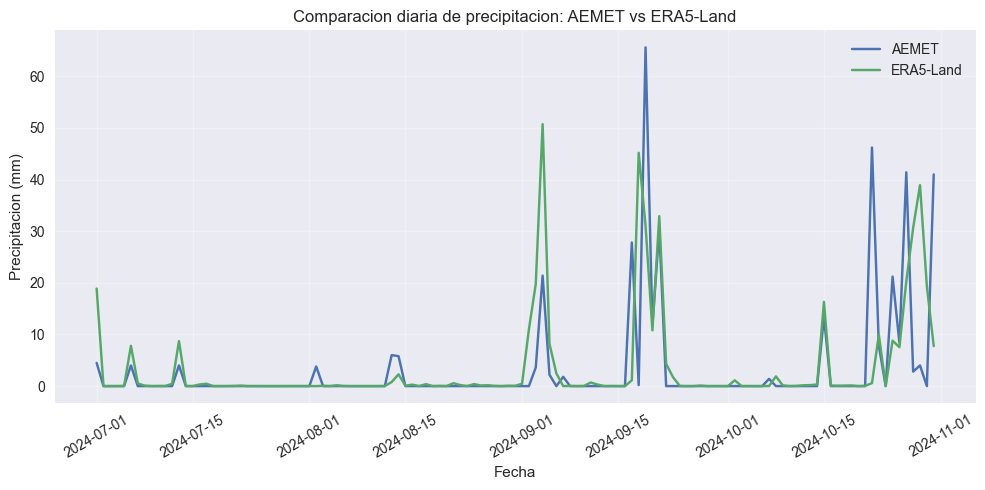

In [25]:
if AEMET_COMPARE_FILE.exists():
    df_aemet_compare = pd.read_csv(AEMET_COMPARE_FILE, parse_dates=["fecha"])

    plt.figure(figsize=(10, 5))
    plt.plot(df_aemet_compare["fecha"], df_aemet_compare["prec"], label="AEMET")
    plt.plot(df_aemet_compare["fecha"], df_aemet_compare["precip_total_dia"], label="ERA5-Land")
    plt.title("Comparacion diaria de precipitacion: AEMET vs ERA5-Land")
    plt.xlabel("Fecha")
    plt.ylabel("Precipitacion (mm)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 5) Preparacion de variables de exposicion territorial (Catastro u otras fuentes)

La incorporacion de `Catastro` u otras capas de exposicion territorial se considera una ampliacion potencial del pipeline, especialmente si las fases posteriores del TFG requieren informacion relacionada con edificacion, parque inmobiliario o intensidad de exposicion municipal.

En la version actual del notebook no se ejecuta todavia una integracion efectiva de estas fuentes, ya que su incorporacion exige una fase previa de descarga, seleccion, armonizacion territorial y evaluacion de utilidad analitica.


En esta entrega no se ejecuta ningun bloque de codigo asociado a `Catastro`, porque no forma parte del dataset enriquecido actual. La fuente queda documentada como ampliacion futura para incorporar variables de exposicion fisica, como edificacion, parque inmobiliario o intensidad urbana, una vez cerrada la base climatica, territorial y socioeconomica principal.

## 6) Decisiones metodologicas y continuidad

La finalidad de este notebook es ampliar de forma modular la base municipal generada en el Notebook 1, manteniendo la trazabilidad del pipeline y evitando integrar fuentes nuevas sin una validacion minima previa. Este enfoque permite escalar el proyecto de manera ordenada y reservar para fases posteriores del TFG el analisis interpretativo y modelizado de las variables ya enriquecidas.

En esta fase queda resuelta la incorporacion de variables municipales del `INE`, que permiten complementar el bloque climatico con informacion demografica, socioeconomica y territorial a escala municipal. Asimismo, se incorpora una validacion externa exploratoria con `AEMET`, util para contrastar de forma preliminar la coherencia del bloque `ERA5-Land`, aunque todavia con limitaciones de cobertura temporal, disponibilidad de estaciones y ausencia de validacion concluyente para temperatura.

Como continuidad del pipeline, quedan abiertas dos lineas principales de trabajo. Por un lado, la ampliacion de la validacion con `AEMET` mediante descargas por tramos o periodos mas amplios que permitan reforzar el contraste externo. Por otro, la incorporacion futura de `Catastro` u otras capas de exposicion territorial, orientadas a enriquecer la caracterizacion espacial del riesgo desde la perspectiva edificatoria o inmobiliaria.
